In [1]:
# =============================
# 1) Imports et configuration
# =============================

import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Pour reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports OK")

Imports OK


In [2]:
# =====================================
# 2) Chargement des données depuis CSV
# =====================================

CSV_PATH = "../data_folder/cache/BTC-USD.csv"  # <-- A adapter


# Lecture CSV
raw_df = pd.read_csv(CSV_PATH)

raw_df.head()

df = raw_df.copy()


In [ ]:
'''# Copie de travail
df = raw_df.copy()

# Conversion en datetime + tri chronologique
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

# Option pertinente pour une série temporelle: date comme index
df = df.set_index("date")

# Tri de sécurité sur l'index temporel
df = df.sort_index()

print("Shape du dataset:", df.shape)
print("Période:", df.index.min(), "->", df.index.max())'''

In [3]:
# ======================================
# 3) Aperçu, types et valeurs manquantes
# ======================================

print("\nAperçu des données:")
display(df.head())

print("\nTypes de colonnes:")
print(df.dtypes)

print("\nValeurs manquantes par colonne:")
print(df.isna().sum())

print("\nStatistiques descriptives:")
display(df.describe().T)


Aperçu des données:


,Date,Open,High,Low,Close,Volume
0,2016-04-12,422.842987,427.277008,422.842987,425.190002,70728800
1,2016-04-13,425.631989,426.657990,422.915985,423.734009,69060400
2,2016-04-14,423.934998,425.371002,423.013000,424.282013,45281000
3,2016-04-15,424.427002,429.928009,424.427002,429.713013,54801500
4,2016-04-16,429.575012,432.625000,428.984009,430.571991,39392800



Types de colonnes:
Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Valeurs manquantes par colonne:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Statistiques descriptives:


,count,mean,std,min,25%,50%,75%,max
Open,3657.0,3.240213e+04,3.256067e+04,4.228430e+02,6.862538e+03,1.997047e+04,5.173054e+04,1.247521e+05
High,3657.0,3.304994e+04,3.310174e+04,4.253710e+02,7.102770e+03,2.034841e+04,5.253391e+04,1.261981e+05
Low,3657.0,3.171365e+04,3.197632e+04,4.228430e+02,6.709070e+03,1.960079e+04,5.051450e+04,1.231960e+05
Close,3657.0,3.242140e+04,3.256343e+04,4.237340e+02,6.867527e+03,1.998671e+04,5.175341e+04,1.247525e+05
Volume,3657.0,2.562529e+10,2.287744e+10,2.851400e+07,6.783120e+09,2.184907e+10,3.700386e+10,3.509679e+11


In [4]:
# =====================
# 4) Création de target
# =====================

horizon = 5  # Nombre de jours dans le futur

# Si close futur > close actuel => target=1, sinon 0
# Note: le dernier(s) point(s) n'a/ont pas de close futur, donc target sera NaN.
df["target"] = (df["Close"].shift(-horizon) > df["Close"]).astype(float)

# On regarde rapidement la distribution de la classe
print("Distribution target (avant dropna final):")
print(df["target"].value_counts(dropna=False))

Distribution target (avant dropna final):
target
1.0    2007
0.0    1650
Name: count, dtype: int64


# Features engineering

In [5]:
# ==============================================
# 5) Fonctions de features techniques (pipeline)
# ==============================================

def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """Calcul simple du RSI (Relative Strength Index)."""
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Moyennes mobiles des gains/pertes
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / (avg_loss + 1e-12)  # epsilon pour stabilité numérique
    rsi = 100 - (100 / (1 + rs))
    return rsi


def build_technical_features(X: pd.DataFrame) -> pd.DataFrame:
    """
    Transforme un DataFrame OHLCV brut en features techniques.

    Important:
    - on travaille uniquement avec informations présentes au temps t
    - pas d'information future utilisée dans les features
    """
    data = X.copy()

    # S'assure que l'ordre temporel est correct
    data = data.sort_index()

    # MAs de base
    data["ma10"] = data["Close"].rolling(10).mean()
    data["ma30"] = data["Close"].rolling(30).mean()
    data["ma50"] = data["Close"].rolling(50).mean()
    data["ma200"] = data["Close"].rolling(200).mean()

    # 1) pente MA200 (variation relative sur 5 jours)
    data["slope_ma200_5d"] = data["ma200"].pct_change(5)

    # 2) MA50
    data["ma50_level"] = data["ma50"]

    # 3) distance spot / MA30
    data["dist_spot_ma30"] = (data["Close"] / (data["ma30"] + 1e-12)) - 1

    # 4) distance spot / MA50
    data["dist_spot_ma50"] = (data["Close"] / (data["ma50"] + 1e-12)) - 1

    # 5) crossover MA10 / MA200
    data["ma10_200_crossover"] = (data["ma10"] / (data["ma200"] + 1e-12)) - 1

    # 6) RSI
    data["rsi14"] = compute_rsi(data["Close"], window=14)

    # 7) volatility ratio 30 / 200
    daily_ret = data["Close"].pct_change()
    vol30 = daily_ret.rolling(30).std()
    vol200 = daily_ret.rolling(200).std()
    data["vol_ratio_30_200"] = vol30 / (vol200 + 1e-12)

    # Features additionnelles
    data["ret_1d"] = daily_ret
    data["mom_5d"] = data["Close"].pct_change(5)
    data["mom_10d"] = data["Close"].pct_change(10)
    data["mom_20d"] = data["Close"].pct_change(20)
    data["daily_range"] = (data["High"] - data["Low"]) / (data["Close"] + 1e-12)
    data["dist_spot_ma200"] = (data["Close"] / (data["ma200"] + 1e-12)) - 1
    data["slope_ma50_5d"] = data["ma50"].pct_change(5)
    data["volume_change_1d"] = data["Volume"].pct_change(1)
    data["rolling_vol_20"] = daily_ret.rolling(20).std()

    # Colonnes finales utilisées par le modèle
    feature_cols = [
        "slope_ma200_5d",
        "ma50_level",
        "dist_spot_ma30",
        "dist_spot_ma50",
        "ma10_200_crossover",
        "rsi14",
        "vol_ratio_30_200",
        "ret_1d",
        "mom_5d",
        "mom_10d",
        "mom_20d",
        "daily_range",
        "dist_spot_ma200",
        "slope_ma50_5d",
        "volume_change_1d",
        "rolling_vol_20",
    ]

    return data[feature_cols]

## 5) Préparation `X` / `y` + split chronologique

In [6]:
df.head()

,Date,Open,High,Low,Close,Volume,target
0,2016-04-12,422.842987,427.277008,422.842987,425.190002,70728800,1.0
1,2016-04-13,425.631989,426.657990,422.915985,423.734009,69060400,1.0
2,2016-04-14,423.934998,425.371002,423.013000,424.282013,45281000,1.0
3,2016-04-15,424.427002,429.928009,424.427002,429.713013,54801500,1.0
4,2016-04-16,429.575012,432.625000,428.984009,430.571991,39392800,1.0


In [7]:
# ==================================================
# 6) Construction de X/y et split temporel explicite
# ==================================================

# Entrées brutes pour le transformer
raw_feature_cols = ["Open", "High", "Low", "Close", "Volume"]
X_raw = df[raw_feature_cols].copy()
y_raw = df["target"].copy()

# Calcul temporaire des features pour trouver les lignes exploitables
X_feat_tmp = build_technical_features(X_raw)

# On conserve uniquement les lignes où features + target sont définies
valid_mask = X_feat_tmp.notna().all(axis=1) & y_raw.notna()
X_raw_clean = X_raw.loc[valid_mask].copy()
y_clean = y_raw.loc[valid_mask].astype(int).copy()

print("Nombre d'observations valides:", len(X_raw_clean))
print("Distribution target finale:")
print(y_clean.value_counts(normalize=True).rename("ratio"))

# Split chronologique (80% train / 20% test)
split_ratio = 0.8
split_idx = int(len(X_raw_clean) * split_ratio)

X_train = X_raw_clean.iloc[:split_idx].copy()
X_test = X_raw_clean.iloc[split_idx:].copy()
y_train = y_clean.iloc[:split_idx].copy()
y_test = y_clean.iloc[split_idx:].copy()

print("\nShapes:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

print("\nPériodes:")
print("Train:", X_train.index.min(), "->", X_train.index.max())
print("Test :", X_test.index.min(), "->", X_test.index.max())

Nombre d'observations valides: 3453
Distribution target finale:
target
1    0.544744
0    0.455256
Name: ratio, dtype: float64

Shapes:
X_train: (2762, 5) | y_train: (2762,)
X_test : (691, 5) | y_test : (691,)

Périodes:
Train: 204 -> 2965
Test : 2966 -> 3656


# Date pivot

In [8]:
index_pivot = df.index[split_idx]
print("\nDate de pivot (train/test):", index_pivot)



Date de pivot (train/test): 2762


In [9]:
date_pivot = df.Date[split_idx]
print("\nDate de pivot (train/test):", date_pivot)


Date de pivot (train/test): 2023-11-04


In [ ]:
# ====================================================
# 7) Construction du pipeline complet avec XGBoost
# ====================================================

feature_transformer = FunctionTransformer(build_technical_features, validate=False)

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,      # L1
    reg_lambda=1.5,     # L2
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Nombre de composantes PCA paramétrable
N_PCA_COMPONENTS = 0.95

pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_transformer),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)),
        ("model", xgb_clf),
    ]
)

print(pipeline)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function build_technical_features at 0x76fcd3dc0680>)),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               c...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=

In [ ]:
# ======================
# 8) Entraînement modèle
# ======================

pipeline.fit(X_train, y_train)

# Prédictions classes
y_pred = pipeline.predict(X_test)

# Prédictions probabilités (classe positive)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Entraînement terminé.")

Entraînement terminé.


Accuracy : 0.4906
Precision: 0.5274
Recall   : 0.2139
F1-score : 0.3043

Classification report:

              precision    recall  f1-score   support

           0     0.4807    0.7915    0.5982       331
           1     0.5274    0.2139    0.3043       360

    accuracy                         0.4906       691
   macro avg     0.5041    0.5027    0.4513       691
weighted avg     0.5050    0.4906    0.4451       691



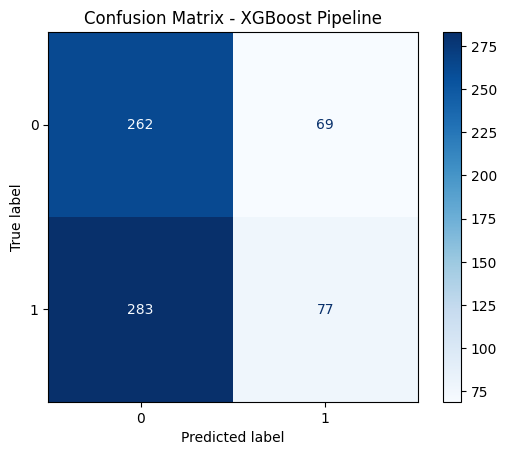


Interprétation rapide:
- Accuracy donne la performance globale.
- Precision mesure la fiabilité des signaux haussiers prédits.
- Recall mesure la capacité à capturer les hausses réelles.
- F1 équilibre precision et recall, utile en cas de classes déséquilibrées.


In [ ]:
# ========================
# 9) Métriques et analyse
# ========================

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost Pipeline")
plt.show()

print("\nInterprétation rapide:")
print("- Accuracy donne la performance globale.")
print("- Precision mesure la fiabilité des signaux haussiers prédits.")
print("- Recall mesure la capacité à capturer les hausses réelles.")
print("- F1 équilibre precision et recall, utile en cas de classes déséquilibrées.")

In [ ]:
# =========================================
# 10) Tuning optionnel avec TimeSeriesSplit
# =========================================

RUN_TUNING = False  # Mettre à True pour lancer la recherche

if RUN_TUNING:
    tscv = TimeSeriesSplit(n_splits=4)

    param_distributions = {
        "pca__n_components": [5, 8, 10, 12],
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_child_weight": [1, 3, 5],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
        "model__reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0],
        "model__learning_rate": [0.01, 0.03, 0.05],
    }

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=20,
        scoring="f1",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    random_search.fit(X_train, y_train)
    print("Meilleurs paramètres:")
    print(random_search.best_params_)
    print("Meilleur score CV (f1):", random_search.best_score_)

    # On remplace le pipeline de base par le meilleur pipeline trouvé
    pipeline = random_search.best_estimator_

    # Ré-entraînement implicite déjà fait par RandomizedSearchCV sur tous les folds,
    # mais on recalcule les prédictions sur test pour comparer proprement.
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("\nMetrics test après tuning:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
else:
    print("Tuning non lancé (RUN_TUNING=False).")

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Meilleurs paramètres:
{'pca__n_components': 10, 'model__subsample': 1.0, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 2, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}
Meilleur score CV (f1): 0.5996132048297482

Metrics test après tuning:
Accuracy : 0.5036
Precision: 0.5344
Recall   : 0.3667
F1-score : 0.4349


In [ ]:
# ==========================
# 11) Sauvegarde du pipeline
# ==========================

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "xgb_pipeline.pkl")

with open(model_path, "wb") as f:
    pickle.dump(pipeline, f)

print(f"Pipeline sauvegardé dans: {model_path}")

Pipeline sauvegardé dans: ../models/xgb_pipeline.pkl


In [ ]:
# Load the model from the pickle file
model_path = os.path.join(ROOT_PATH, 'models', 'best_model.pkl')
with open(model_path, 'rb') as file:
     model = pickle.load(file)

In [ ]:
df.tail()

,Date,Open,High,Low,Close,Volume,target
3652,2026-04-12,73056.046875,73154.031250,70540.570312,70753.406250,29882740487,0.0
3653,2026-04-13,70757.617188,74896.312500,70588.523438,74484.640625,52278211554,0.0
3654,2026-04-14,74478.398438,76061.757812,73877.203125,74181.609375,53540826530,0.0
3655,2026-04-15,74182.023438,75409.273438,73549.203125,74805.078125,38090174312,0.0
3656,2026-04-16,74810.875000,75506.570312,73346.265625,75152.132812,41312783855,0.0


In [10]:
# =====================================
# 12.1) Imports spécifiques au Deep Learning
# =====================================

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

I0000 00:00:1776613181.412186  309012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776613181.421403  309012 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776613182.811787  309012 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776613183.614526  309012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

TensorFlow version: 2.21.0


In [11]:
# ==========================================
# 12.2) Préparation features + séquences RNN
# ==========================================

# Recalcul des features sur l'échantillon propre (même base que XGBoost)
X_features_full = build_technical_features(X_raw_clean)
y_full = y_clean.copy()

# Sécurité: on aligne encore les index et supprime éventuels NaN restants
valid_rnn_mask = X_features_full.notna().all(axis=1) & y_full.notna()
X_features_full = X_features_full.loc[valid_rnn_mask].copy()
y_full = y_full.loc[valid_rnn_mask].astype(int).copy()

# Split chrono (même logique 80/20)
split_idx_rnn = int(len(X_features_full) * split_ratio)

X_train_feat = X_features_full.iloc[:split_idx_rnn].copy()
X_test_feat = X_features_full.iloc[split_idx_rnn:].copy()
y_train_feat = y_full.iloc[:split_idx_rnn].copy()
y_test_feat = y_full.iloc[split_idx_rnn:].copy()

# Scaling: fit UNIQUEMENT sur le train
rnn_scaler = StandardScaler()
X_train_scaled = rnn_scaler.fit_transform(X_train_feat)
X_test_scaled = rnn_scaler.transform(X_test_feat)

print("Train features:", X_train_scaled.shape)
print("Test features :", X_test_scaled.shape)

Train features: (2599, 16)
Test features : (650, 16)


In [12]:
# ==========================================
# 12.3) Fonction utilitaire de création séquences
# ==========================================

def make_sequences(features_array: np.ndarray, target_array: np.ndarray, lookback: int):
    """
    Construit des séquences de taille `lookback`.

    Exemple:
    - X[t-lookback:t] -> y[t]

    Ce schéma n'utilise que le passé pour prédire le présent/futur proche.
    """
    X_seq, y_seq = [], []
    for i in range(lookback, len(features_array)):
        X_seq.append(features_array[i - lookback : i])
        y_seq.append(target_array[i])
    return np.array(X_seq), np.array(y_seq)


LOOKBACK = 30  # Longueur de séquence (30 jours)

# Séquences train
X_train_seq, y_train_seq = make_sequences(
    X_train_scaled,
    y_train_feat.values,
    lookback=LOOKBACK,
)

# Pour le test, on ajoute un contexte de LOOKBACK points de train
# afin de former les premières séquences de test sans fuite future.
X_test_with_context = np.vstack([X_train_scaled[-LOOKBACK:], X_test_scaled])
y_test_with_context = np.concatenate([y_train_feat.values[-LOOKBACK:], y_test_feat.values])

X_test_seq, y_test_seq = make_sequences(
    X_test_with_context,
    y_test_with_context,
    lookback=LOOKBACK,
)

print("X_train_seq:", X_train_seq.shape, "| y_train_seq:", y_train_seq.shape)
print("X_test_seq :", X_test_seq.shape, "| y_test_seq :", y_test_seq.shape)
print("n_features utilisés:", X_train_seq.shape[-1])

X_train_seq: (2569, 30, 16) | y_train_seq: (2569,)
X_test_seq : (650, 30, 16) | y_test_seq : (650,)
n_features utilisés: 16


In [13]:
# ======================================
# 12.4) Modèle RNN + entraînement
# ======================================

tf.random.set_seed(RANDOM_STATE)

n_features = X_train_seq.shape[-1]

rnn_model = Sequential(
    [
        Input(shape=(LOOKBACK, n_features)),
        SimpleRNN(32, activation="tanh"),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = rnn_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,  # Important pour cohérence temporelle
    callbacks=[early_stopping],
    verbose=1,
)

print("Entraînement RNN terminé.")

E0000 00:00:1776613357.728359  309012 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5139 - loss: 0.7169 - val_accuracy: 0.5078 - val_loss: 0.7099
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5440 - loss: 0.6943 - val_accuracy: 0.4981 - val_loss: 0.7029
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5309 - loss: 0.6937 - val_accuracy: 0.4981 - val_loss: 0.7032
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5547 - loss: 0.6844 - val_accuracy: 0.5117 - val_loss: 0.7022
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ -2s -36906us/step - accuracy: 0.5650 - loss: 0.6757 - val_accuracy: 0.5214 - val_loss: 0.7043
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5703 - loss: 0.6746 - val_accuracy: 0.5156 - val_loss: 0.7046
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5937 - loss: 0.6644 - val_accuracy: 0.5195 - val_loss: 0.7088
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5956 - loss: 0.6605 - val_accuracy: 0.4747 - va

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
RNN Accuracy : 0.4600
RNN Precision: 0.4651
RNN Recall   : 0.0575
RNN F1-score : 0.1023

RNN Classification report:

              precision    recall  f1-score   support

           0     0.4596    0.9238    0.6139       302
           1     0.4651    0.0575    0.1023       348

    accuracy                         0.4600       650
   macro avg     0.4624    0.4907    0.3581       650
weighted avg     0.4626    0.4600    0.3400       650



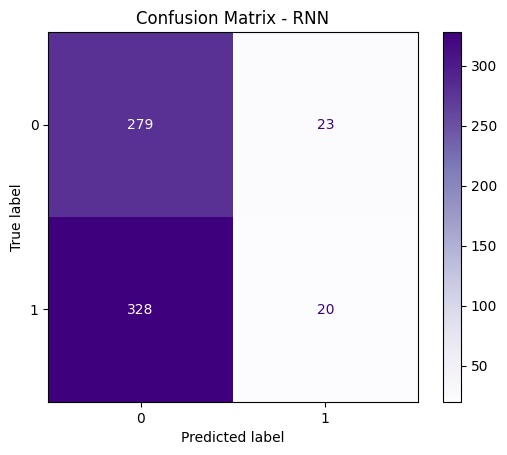

In [14]:
# ======================
# 12.5) Évaluation RNN
# ======================

# Probabilités et classes
rnn_proba = rnn_model.predict(X_test_seq).ravel()
rnn_pred = (rnn_proba >= 0.5).astype(int)

# Métriques
rnn_acc = accuracy_score(y_test_seq, rnn_pred)
rnn_prec = precision_score(y_test_seq, rnn_pred, zero_division=0)
rnn_rec = recall_score(y_test_seq, rnn_pred, zero_division=0)
rnn_f1 = f1_score(y_test_seq, rnn_pred, zero_division=0)

print(f"RNN Accuracy : {rnn_acc:.4f}")
print(f"RNN Precision: {rnn_prec:.4f}")
print(f"RNN Recall   : {rnn_rec:.4f}")
print(f"RNN F1-score : {rnn_f1:.4f}")

print("\nRNN Classification report:\n")
print(classification_report(y_test_seq, rnn_pred, digits=4))

rnn_cm = confusion_matrix(y_test_seq, rnn_pred)
rnn_disp = ConfusionMatrixDisplay(confusion_matrix=rnn_cm, display_labels=[0, 1])
rnn_disp.plot(cmap="Purples")
plt.title("Confusion Matrix - RNN")
plt.show()

In [ ]:
# ========================
# 12.6) Sauvegarde du RNN
# ========================

os.makedirs("model", exist_ok=True)

# Sauvegarde du modèle neuronal
rnn_model_path = os.path.join("models", "rnn_direction_model.keras")
rnn_model.save(rnn_model_path)

# Sauvegarde du scaler + paramètres nécessaires
rnn_artifacts = {
    "scaler": rnn_scaler,
    "lookback": LOOKBACK,
    "feature_columns": list(X_features_full.columns),
}

rnn_artifacts_path = os.path.join("../models", "rnn_preprocessing.pkl")
with open(rnn_artifacts_path, "wb") as f:
    pickle.dump(rnn_artifacts, f)

print(f"RNN sauvegardé: {rnn_model_path}")
print(f"Artifacts sauvegardés: {rnn_artifacts_path}")

RNN sauvegardé: model/rnn_direction_model.keras
Artifacts sauvegardés: ../models/rnn_preprocessing.pkl


# Deribit

In [2]:
# =========================================
# 13.1) Configuration Deribit testnet
# =========================================

import os
import math
import requests

DERIBIT_TEST_URL = "https://test.deribit.com/api/v2"
#DERIBIT_CLIENT_ID = os.getenv("DERIBIT_CLIENT_ID")
#DERIBIT_CLIENT_SECRET = os.getenv("DERIBIT_CLIENT_SECRET")
DERIBIT_CLIENT_ID = "KsGK55_7"
DERIBIT_CLIENT_SECRET = "IYhENyr_lmsMW1iUImdE84l1-aGbXpf9R4A2KdHiti4"


# Instrument spot BTC/USDC (ajustable)
DERIBIT_INSTRUMENT = "BTC_USDC"

# Notionnel à engager si signal = 1
ORDER_NOTIONAL_USD = 10_000

# Sécurité: True = ne passe pas l'ordre, affiche seulement le payload
#DRY_RUN = True
DRY_RUN = False

if DERIBIT_CLIENT_ID is None or DERIBIT_CLIENT_SECRET is None:
    print("Variables d'environnement manquantes: DERIBIT_CLIENT_ID / DERIBIT_CLIENT_SECRET")
    print("Ajoute-les avant d'exécuter un ordre réel.")

In [3]:
# =========================================
# 13.2) Helpers API Deribit
# =========================================

def deribit_get_access_token(client_id: str, client_secret: str) -> str:
    # Utilise JSON-RPC en POST pour éviter d'exposer le secret dans l'URL
    payload = {
        "jsonrpc": "2.0",
        "id": 1,
        "method": "public/auth",
        "params": {
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret,
        },
    }
    resp = requests.post(DERIBIT_TEST_URL, json=payload, timeout=15)
    data = resp.json()

    if resp.status_code >= 400 or data.get("error"):
        raise RuntimeError(f"Auth Deribit échouée: {data}")

    token = data.get("result", {}).get("access_token")
    if not token:
        raise RuntimeError(f"Réponse auth inattendue: {data}")
    return token


def deribit_get_last_price(instrument_name: str) -> float:
    resp = requests.get(
        f"{DERIBIT_TEST_URL}/public/ticker",
        params={"instrument_name": instrument_name},
        timeout=15,
    )
    data = resp.json()
    if resp.status_code >= 400 or "result" not in data or "last_price" not in data["result"]:
        raise RuntimeError(f"Ticker Deribit invalide: {data}")
    return float(data["result"]["last_price"])


def deribit_get_instrument(instrument_name: str) -> dict:
    resp = requests.get(
        f"{DERIBIT_TEST_URL}/public/get_instrument",
        params={"instrument_name": instrument_name},
        timeout=15,
    )
    data = resp.json()
    if resp.status_code >= 400 or "result" not in data:
        raise RuntimeError(f"get_instrument: {data}")
    return data["result"]


def deribit_floor_amount_to_contract(amount: float, contract_size: float) -> float:
    """Deribit: amount doit être un multiple exact de contract_size (ex. spot BTC_USDC: 0.0001)."""
    if contract_size <= 0:
        return amount
    n = math.floor(amount / contract_size)
    return n * contract_size


def deribit_place_market_buy_spot(
    access_token: str,
    instrument_name: str,
    amount_btc: float,
):
    # JSON-RPC pour obtenir une erreur explicite côté Deribit
    payload = {
        "jsonrpc": "2.0",
        "id": 2,
        "method": "private/buy",
        "params": {
            "instrument_name": instrument_name,
            "type": "market",
            "amount": float(amount_btc),
        },
    }
    resp = requests.post(
        DERIBIT_TEST_URL,
        json=payload,
        headers={"Authorization": f"Bearer {access_token}"},
        timeout=15,
    )
    data = resp.json()
    if resp.status_code >= 400 or data.get("error"):
        raise RuntimeError(f"Erreur Deribit private/buy: {data}")
    return data

In [4]:
# =========================================
# 13.3) Test auth Deribit (sans ordre)
# =========================================

def test_auth_only() -> bool:
    if DERIBIT_CLIENT_ID is None or DERIBIT_CLIENT_SECRET is None:
        print("Clés manquantes: DERIBIT_CLIENT_ID / DERIBIT_CLIENT_SECRET")
        return False

    try:
        token = deribit_get_access_token(DERIBIT_CLIENT_ID, DERIBIT_CLIENT_SECRET)
        print("Auth Deribit OK (testnet).")
        print(f"Token reçu (aperçu): {token[:12]}...")
        return True
    except Exception as e:
        print("Auth Deribit KO.")
        print("Vérifie: clés testnet, permissions API, et absence d'espaces dans les variables.")
        print(f"Détail erreur: {e}")
        return False

# Exécution du test
_ = test_auth_only()

Auth Deribit OK (testnet).
Token reçu (aperçu): 177663190177...


In [5]:
# =========================================
# 13.4) Vérification des permissions API (sans ordre)
# =========================================

def check_deribit_api_permissions() -> bool:
    if DERIBIT_CLIENT_ID is None or DERIBIT_CLIENT_SECRET is None:
        print("Clés manquantes: DERIBIT_CLIENT_ID / DERIBIT_CLIENT_SECRET")
        return False

    payload = {
        "jsonrpc": "2.0",
        "id": 99,
        "method": "public/auth",
        "params": {
            "grant_type": "client_credentials",
            "client_id": DERIBIT_CLIENT_ID,
            "client_secret": DERIBIT_CLIENT_SECRET,
        },
    }

    try:
        resp = requests.post(DERIBIT_TEST_URL, json=payload, timeout=15)
        data = resp.json()

        if resp.status_code >= 400 or data.get("error"):
            print("Impossible de vérifier les permissions (auth KO).")
            print(f"Détail: {data}")
            return False

        scope = data.get("result", {}).get("scope", "")
        scope_items = scope.split()

        print("Auth OK. Scopes reçus:")
        print(scope_items)

        has_trade = any(item.startswith("trade:") for item in scope_items)
        if has_trade:
            print("Permission trade détectée: OK")
        else:
            print("Permission trade non détectée: KO")
            print("Recrée la clé testnet avec droits de trading.")

        return has_trade

    except Exception as e:
        print("Erreur pendant la vérification des permissions.")
        print(f"Détail erreur: {e}")
        return False

# Exécution du check
_ = check_deribit_api_permissions()

Auth OK. Scopes reçus:
['session:rest-jE0RWRx9uIA=', 'trade:read_write', 'mainaccount']
Permission trade détectée: OK


In [6]:
# =========================================
# 13.3) Exécution conditionnelle: prediction == 1
# =========================================

# Source du signal (par défaut: dernière prédiction XGBoost)
#latest_prediction = int(y_pred[-1])
latest_prediction = 1

print(f"Dernière prédiction = {latest_prediction}")

if latest_prediction != 1:
    print("Signal != 1: aucun ordre envoyé.")
else:
    if DERIBIT_CLIENT_ID is None or DERIBIT_CLIENT_SECRET is None:
        raise ValueError("DERIBIT_CLIENT_ID / DERIBIT_CLIENT_SECRET non définis.")

    inst = deribit_get_instrument(DERIBIT_INSTRUMENT)
    contract_size = float(inst["contract_size"])
    min_trade = float(inst["min_trade_amount"])

    last_price = deribit_get_last_price(DERIBIT_INSTRUMENT)
    raw_btc = ORDER_NOTIONAL_USD / last_price
    amount_btc = deribit_floor_amount_to_contract(raw_btc, contract_size)

    print(f"Prix {DERIBIT_INSTRUMENT}: {last_price:.2f} USDC")
    print(f"contract_size (pas mini): {contract_size} BTC, min_trade_amount: {min_trade} BTC")
    print(f"Quantité BTC (multiple de contract_size): {amount_btc} (~{amount_btc * last_price:,.2f} USDC)")

    if amount_btc < min_trade:
        raise ValueError(
            f"Quantité {amount_btc} BTC < min_trade_amount {min_trade} BTC — augmente ORDER_NOTIONAL_USD ou vérifie l'instrument."
        )

    if DRY_RUN:
        print("DRY_RUN=True -> ordre non envoyé")
        print(
            {
                "instrument_name": DERIBIT_INSTRUMENT,
                "type": "market",
                "amount": amount_btc,
                "estimated_notional_usd": ORDER_NOTIONAL_USD,
            }
        )
    else:
        try:
            token = deribit_get_access_token(DERIBIT_CLIENT_ID, DERIBIT_CLIENT_SECRET)
            order_result = deribit_place_market_buy_spot(
                access_token=token,
                instrument_name=DERIBIT_INSTRUMENT,
                amount_btc=amount_btc,
            )
            print("Ordre envoyé sur Deribit testnet:")
            print(order_result)
        except Exception as e:
            print("Echec envoi ordre Deribit.")
            print("Causes fréquentes: amount pas multiple de contract_size, solde testnet insuffisant, ou erreur API.")
            raise

Dernière prédiction = 1
Prix BTC_USDC: 76009.00 USDC
contract_size (pas mini): 0.0001 BTC, min_trade_amount: 0.0001 BTC
Quantité BTC (multiple de contract_size): 0.1315 (~9,995.18 USDC)
Ordre envoyé sur Deribit testnet:
{'jsonrpc': '2.0', 'id': 2, 'result': {'order': {'label': '', 'price': 76347.0, 'amount': 0.1315, 'user_id': 78709, 'direction': 'buy', 'time_in_force': 'good_til_cancelled', 'instrument_name': 'BTC_USDC', 'web': False, 'api': True, 'order_id': 'BTC_USDC-957374125', 'creation_timestamp': 1776631015282, 'replaced': False, 'post_only': False, 'mmp': False, 'filled_amount': 0.1315, 'last_update_timestamp': 1776631015282, 'average_price': 76034.0, 'contracts': 1315.0, 'order_state': 'filled', 'order_type': 'market', 'is_rebalance': False, 'risk_reducing': False}, 'trades': [{'timestamp': 1776631015282, 'state': 'filled', 'price': 76034.0, 'amount': 0.1315, 'trade_id': 'BTC_USDC-19472067', 'user_id': 78709, 'direction': 'buy', 'index_price': 74849.2, 'instrument_name': 'BTC_

Dernière prédiction = 1
Prix BTC_USDC: 76034.00 USDC
Quantité BTC calculée pour 10000 USD: 0.13152
DRY_RUN=True -> ordre non envoyé
{'instrument_name': 'BTC_USDC', 'type': 'market', 'amount': 0.13152, 'estimated_notional_usd': 10000}
